# Entrenamiento y Evaluación Comparativa (TFM)

> Modelos: **MobileNetV2 SSD** y **YOLOv11 Optimizado**

> Objetivo: flujo reproducible de entrenamiento, validación, test y comparación final.

## Paso 1 — Estructura del proyecto y configuración global

Este bloque inicializa rutas, estructura de carpetas y parámetros base comunes a ambos modelos.

In [3]:
# Configuración base y estructura de carpetas
from __future__ import annotations

import os
import sys
import random
import numpy as np

# Asegurar imports desde 02_ING_MODELOS/src
PROJECT_ROOT = "/Users/admin/Documents/TFM_UNIR"
SRC_PATH = os.path.join(PROJECT_ROOT, "02_ING_MODELOS", "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Verify the path exists
if not os.path.exists(SRC_PATH):
    raise FileNotFoundError(f"SRC_PATH does not exist: {SRC_PATH}")

try:
    from utils_config import ProjectConfig
    from utils_io import log, safe_exists
except ImportError as e:
    print(f"Import error: {e}")
    print(f"Current sys.path: {sys.path}")
    print(f"Files in SRC_PATH: {os.listdir(SRC_PATH) if os.path.exists(SRC_PATH) else 'Path does not exist'}")
    raise

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Inicializar configuración de proyecto
config = ProjectConfig(base_project_dir=PROJECT_ROOT)
config.ensure_dirs()

# Verificaciones rápidas de datos
log("📁 Verificando rutas de dataset...")
log(f"   TRAIN JSON: {config.train_json} -> {'OK' if safe_exists(config.train_json) else 'MISSING'}")
log(f"   VAL JSON:   {config.val_json} -> {'OK' if safe_exists(config.val_json) else 'MISSING'}")
log(f"   TEST JSON:  {config.test_json} -> {'OK' if safe_exists(config.test_json) else 'MISSING'}")
log("✅ Configuración global inicializada.")

🔧 Verificando estructura de carpetas...
📁 Verificando rutas de dataset...
   TRAIN JSON: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented2_images/train_final2.json -> OK
   VAL JSON:   /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/valid/val_final.json -> OK
   TEST JSON:  /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/test_final.json -> OK
✅ Configuración global inicializada.


In [4]:
# Parámetros base (extraídos de configuraciones.md)
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]
COCO_TO_IDX = {2: 0, 5: 1, 6: 2, 7: 3}

BASELINE_CONFIG = {
    "yolo_v1": {
        "model": "yolo11n.pt",
        "imgsz": 224,
        "epochs": 100,
        "batch": 32,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "lrf": 0.01,
        "weight_decay": 0.0005,
        "warmup_epochs": 3,
        "mosaic": 0.3,
        "scale": 0.1,
        "fliplr": 0.3,
        "hsv_s": 0.1,
        "hsv_v": 0.1,
    },
    "ssd_v6": {
        "backbone": "MobileNetV2",
        "alpha": 0.50,
        "input_size": 224,
        "max_objects": 2,
        "batch": 32,
    },
}

log("🧩 Baselines cargados (YOLO V1, SSD V6).")
log(f"   Clases: {CLASS_NAMES}")
log(f"   SSD max_objects: {BASELINE_CONFIG['ssd_v6']['max_objects']}")

🧩 Baselines cargados (YOLO V1, SSD V6).
   Clases: ['door', 'footpath', 'obstacle', 'person']
   SSD max_objects: 2


## Paso 2 — MobileNetV2 SSD (ajustes solicitados)

Objetivo de este paso:
- Salida **dinámica** basada en anchors (no bboxes fijos).
- **Class weights** para compensar desbalance.
- **Aspect ratios** ajustados para objetos verticales (`person`, `door`) y horizontales (`footpath`).

In [5]:
# Anchors y aspect ratios ajustados (vertical/horizontal)
from utils_ssd_anchors import compute_kmeans_anchors, derive_aspect_ratios, generate_anchors, log_anchor_summary
from utils_io import log

# Configuración base de anchors
FEATURE_MAP_SIZE = 7  # MobileNetV2 output para input 224 (aprox 7x7)
SCALES = [0.10, 0.20, 0.35]  # escalas base (ajustables)

# Intentar derivar aspect ratios desde K-Means (si scikit-learn está disponible)
try:
    kmeans_anchors = compute_kmeans_anchors(config.train_json, n_clusters=6)
    aspect_ratios = derive_aspect_ratios(kmeans_anchors)
    log(f"✅ Aspect ratios derivados por K-Means: {np.round(aspect_ratios, 2)}")
except Exception as exc:
    # Fallback: ratios manuales balanceados para vertical/horizontal
    aspect_ratios = [0.33, 0.50, 1.0, 2.0, 3.0]
    log(f"⚠️ K-Means no disponible: {exc}")
    log(f"   Usando aspect ratios manuales: {aspect_ratios}")

ANCHORS = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=SCALES,
    aspect_ratios=aspect_ratios,
)
log_anchor_summary(ANCHORS)

ANCHORS_PER_CELL = len(SCALES) * len(aspect_ratios)
log(f"🔧 Anchors por celda: {ANCHORS_PER_CELL}")
log(f"🔧 Total anchors: {ANCHORS.shape[0]}")

✅ Aspect ratios derivados por K-Means: [0.5  0.7  0.93 1.   1.47 3.02]
📦 Anchors: 882
   Area min/max: 0.0100 / 0.1225
   w min/max: 0.0710 / 0.6082
   h min/max: 0.0575 / 0.4933
🔧 Anchors por celda: 18
🔧 Total anchors: 882


In [6]:
# Class weights para SSD (incluye background explícito)
import glob
from collections import Counter
from utils_io import log

train_lbl_dir = os.path.join(config.dirs["yolo_dataset"], "labels", "train")
label_files = glob.glob(os.path.join(train_lbl_dir, "*.txt"))
class_counter = Counter()

for txt_path in label_files:
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            class_counter[cls_id] += 1

num_classes = len(CLASS_NAMES)
total_objects = sum(class_counter.values())
log(f"📊 Conteo de clases (objetos): {dict(class_counter)}")
log(f"📊 Total objetos: {total_objects}")

# Pesos inversamente proporcionales (capados)
max_weight = 50.0
class_weights = np.ones(num_classes + 1, dtype=np.float32)  # +1 background
for cls_id in range(num_classes):
    count = class_counter.get(cls_id, 1)
    weight = total_objects / (num_classes * count)
    class_weights[cls_id + 1] = min(max_weight, weight)

# Fondo se deja en 1.0 para no dominar
class_weights[0] = 1.0
log(f"⚖️ Class weights (bg + clases): {np.round(class_weights, 2)}")

📊 Conteo de clases (objetos): {2: 1431, 1: 486, 0: 252, 3: 270}
📊 Total objetos: 2439
⚖️ Class weights (bg + clases): [1.   2.42 1.25 0.43 2.26]


In [15]:
# Modelo SSD con salida dinámica (anchors)
from utils_ssd_model import build_mobilenet_ssd_anchor_head
from utils_ssd_losses import masked_bbox_smooth_l1_loss, weighted_categorical_crossentropy
from utils_ssd_data import SSDAnchorDataGenerator
import tensorflow as tf

ssd_anchor_model = build_mobilenet_ssd_anchor_head(
    input_shape=(BASELINE_CONFIG["ssd_v6"]["input_size"],) * 2 + (3,),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=BASELINE_CONFIG["ssd_v6"]["alpha"],
    feature_channels=256,
    use_batchnorm=True,
    model_name="MobileNetV2_SSD_Anchors",
)
ssd_anchor_model.summary()

# Losses (con pesos de clase)
cls_loss = weighted_categorical_crossentropy(class_weights)
ssd_anchor_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
    loss={
        "class_out": cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={"class_out": 1.0, "bbox_out_sigmoid": 1.0},
    metrics={"class_out": "accuracy"},
)
log("✅ SSD anchor-based compilado (salida dinámica por anchors).")

# Generadores anchor-based (train/val)
train_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)
val_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)
log("✅ Generadores SSD anchor-based listos.")

Model: "MobileNetV2_SSD_Anchors"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 3,698,002 (14.11 MB)

 Trainable params: 3,678,946 (14.03 MB)

 Non-trainable params: 19,056 (74.44 KB)

✅ SSD anchor-based compilado (salida dinámica por anchors).
✅ Generadores SSD anchor-based listos.


In [17]:
# 🔄 Recarga de módulos SSD + sanity check (evita caché en notebook)
import importlib
import utils_ssd_model as _ssd_model
import utils_ssd_data as _ssd_data
import utils_ssd_losses as _ssd_losses

importlib.reload(_ssd_model)
importlib.reload(_ssd_data)
importlib.reload(_ssd_losses)

from utils_ssd_model import build_mobilenet_ssd_anchor_head
from utils_ssd_losses import masked_bbox_smooth_l1_loss, weighted_categorical_crossentropy
from utils_ssd_data import SSDAnchorDataGenerator

# Re-construir modelo (para asegurar outputs correctos)
ssd_anchor_model = build_mobilenet_ssd_anchor_head(
    input_shape=(BASELINE_CONFIG["ssd_v6"]["input_size"],) * 2 + (3,),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=BASELINE_CONFIG["ssd_v6"]["alpha"],
    feature_channels=256,
    use_batchnorm=True,
    model_name="MobileNetV2_SSD_Anchors",
)
cls_loss = weighted_categorical_crossentropy(class_weights)
ssd_anchor_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
    loss={
        "class_out": cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={"class_out": 1.0, "bbox_out_sigmoid": 1.0},
    metrics={"class_out": "accuracy"},
)

# Re-construir generadores (asegura llaves correctas)
train_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)
val_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)

# Sanity check de salida del generador
x_batch, y_batch = train_gen_ssd_anchor[0]
print("✅ y_batch keys:", list(y_batch.keys()))
bbox_key = "bbox_out_sigmoid" if "bbox_out_sigmoid" in y_batch else "bbox_out"
print("✅ dtypes:", y_batch["class_out"].dtype, y_batch[bbox_key].dtype)

✅ y_batch keys: ['class_out', 'bbox_out_sigmoid']
✅ dtypes: float32 float32


## Paso 3 — Entrenamiento y validación (SSD anchors)

Entrenamos el SSD con salida dinámica usando callbacks y guardamos el historial para análisis.

In [18]:
# Entrenamiento SSD (anchor-based)
from utils_training import create_callbacks
import pandas as pd
import matplotlib.pyplot as plt

SSD_MODEL_NAME = "ssd_anchor_v1"
SSD_EPOCHS = 50

ssd_callbacks = create_callbacks(
    model_name=SSD_MODEL_NAME,
    logs_dir=config.dirs["logs"],
    checkpoints_dir=config.dirs["models_chk"],
    monitor="val_loss",
    mode="min",
    patience_early=8,
    patience_lr=4,
)

print("\n--- ENTRENANDO SSD ANCHOR-BASED ---")
history_ssd = ssd_anchor_model.fit(
    train_gen_ssd_anchor,
    validation_data=val_gen_ssd_anchor,
    epochs=SSD_EPOCHS,
    callbacks=ssd_callbacks,
    verbose=1,
)

# Guardar modelo final
final_path = os.path.join(config.dirs["models_final"], f"{SSD_MODEL_NAME}.keras")
ssd_anchor_model.save(final_path)
print(f"✅ Modelo SSD guardado en: {final_path}")

# Guardar historial en CSV
hist_df = pd.DataFrame(history_ssd.history)
hist_path = os.path.join(config.dirs["logs"], f"{SSD_MODEL_NAME}_history.csv")
hist_df.to_csv(hist_path, index=False)
print(f"✅ Historial guardado en: {hist_path}")

✅ Callbacks configurados para 'ssd_anchor_v1'

--- ENTRENANDO SSD ANCHOR-BASED ---
Epoch 1/50


2026-02-02 17:25:26.168560: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - bbox_out_sigmoid_loss: 0.0273 - class_out_accuracy: 0.6370 - class_out_loss: 1.0775 - loss: 1.1055
Epoch 1: val_loss improved from None to 0.19509, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v1_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - bbox_out_sigmoid_loss: 0.0195 - class_out_accuracy: 0.8446 - class_out_loss: 0.6565 - loss: 0.6782 - val_bbox_out_sigmoid_loss: 0.0209 - val_class_out_accuracy: 0.9944 - val_class_out_loss: 0.1710 - val_loss: 0.1951 - learning_rate: 5.0000e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_out_sigmoid_loss: 0.0071 - class_out_accuracy: 0.9938 - class_out_loss: 0.1054 - loss: 0.1126
Epoch 2: val_loss improved from 0.19509 to 0.08184, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v1_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - bbox_out_sigmoid_loss: 0.0058 - class_out_accuracy: 0.9942 - class_ou

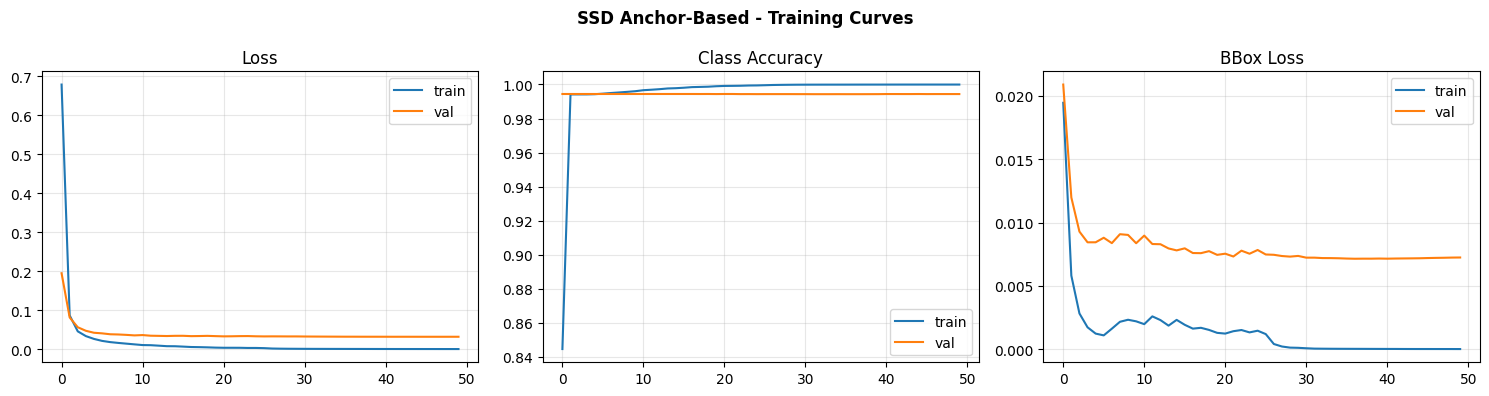

In [19]:
# Gráficos básicos de entrenamiento
def plot_history(history_df: pd.DataFrame, title: str = "SSD Anchor Training"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    # Loss total
    if 'loss' in history_df.columns:
        axes[0].plot(history_df['loss'], label='train')
    if 'val_loss' in history_df.columns:
        axes[0].plot(history_df['val_loss'], label='val')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Class accuracy
    acc_cols = [c for c in history_df.columns if 'class_out_accuracy' in c]
    if acc_cols:
        axes[1].plot(history_df[acc_cols[0]], label='train')
    if 'val_class_out_accuracy' in history_df.columns:
        axes[1].plot(history_df['val_class_out_accuracy'], label='val')
    axes[1].set_title('Class Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # BBox loss (si existe)
    bbox_cols = [c for c in history_df.columns if 'bbox_out' in c and 'loss' in c]
    if bbox_cols:
        axes[2].plot(history_df[bbox_cols[0]], label='train')
    val_bbox_cols = [c for c in history_df.columns if c.startswith('val_') and 'bbox_out' in c and 'loss' in c]
    if val_bbox_cols:
        axes[2].plot(history_df[val_bbox_cols[0]], label='val')
    axes[2].set_title('BBox Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(hist_df, title="SSD Anchor-Based - Training Curves")

## Paso 3.1 — Evaluación en test (SSD anchor-based)

Métricas en el conjunto de test usando el modelo SSD entrenado.

In [ ]:
# Evaluación SSD en test
from utils_test_loader import COCOTargets
from utils_ssd_infer import run_ssd_inference
from utils_eval import evaluate_model
import numpy as np

TEST_IMG_SIZE = BASELINE_CONFIG["ssd_v6"]["input_size"]
test_loader = COCOTargets(
    coco_json_path=config.test_json,
    images_dir=config.test_img_dir,
    class_names=CLASS_NAMES,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
)

ssd_results = []
for images, gts, ids in test_loader.iter_batches(batch_size=8):
    images = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model,
        image_batch=images,
        class_names=CLASS_NAMES,
        image_ids=ids, # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME,
        conf_threshold=0.30,
        nms_iou=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    )
    ssd_results.extend(batch_results)

ssd_metrics = evaluate_model(SSD_MODEL_NAME, ssd_results, CLASS_NAMES)
print("\n📊 SSD Test Metrics")
print(f"mAP@50: {ssd_metrics.map_50:.4f}")
print(f"Precision: {ssd_metrics.precision:.4f} | Recall: {ssd_metrics.recall:.4f} | F1: {ssd_metrics.f1_score:.4f}")
print(f"Detection Acc: {ssd_metrics.detection_accuracy:.4f} | Avg IoU: {ssd_metrics.avg_iou:.4f}")
print(f"Avg Inference Time (ms/img): {ssd_metrics.inference_time_ms:.2f}")

Loaded 84 images and 40 annotations.

📊 SSD Test Metrics
mAP@50: 0.0000
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Detection Acc: 0.5714 | Avg IoU: 0.0000
Avg Inference Time (ms/img): 15.42


## Paso 3.2 — Visualizador de muestras (SSD)

Muestra algunas detecciones del test set para inspección cualitativa.

Predicciones totales en muestras: 31


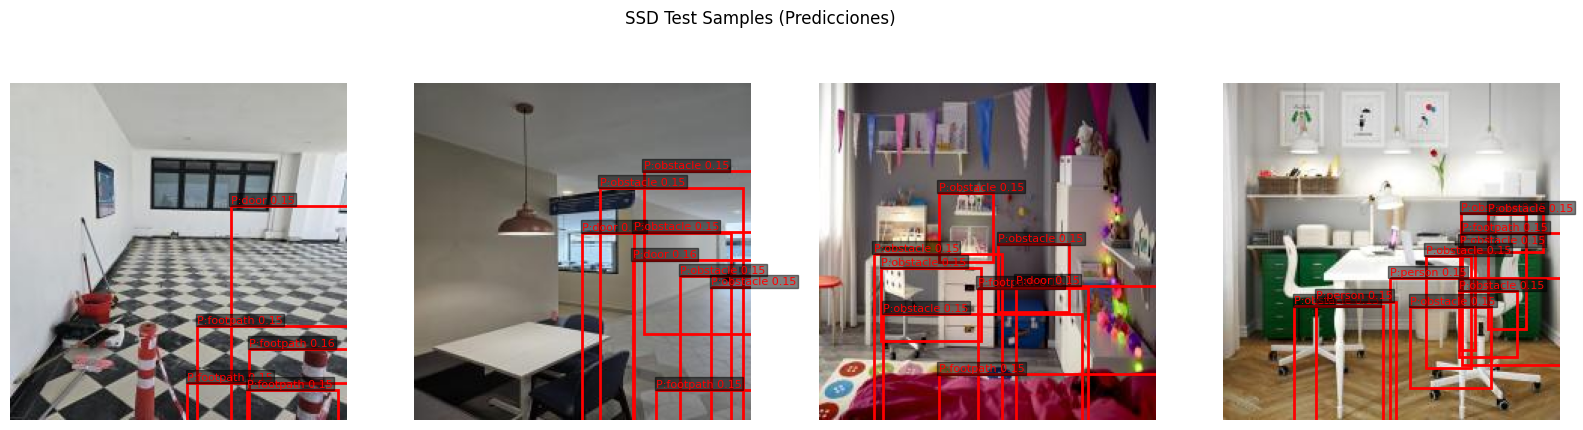

In [ ]:
# Visualizar detecciones SSD en algunas imágenes
import importlib
import utils_ssd_infer as _ssd_infer
from utils_viz import show_random_samples

importlib.reload(_ssd_infer)
from utils_ssd_infer import run_ssd_inference

sample_images = []
sample_gts = []
sample_preds = []
total_preds = 0
for images, gts, ids in test_loader.iter_batches(batch_size=4):
    images_norm = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model,
        image_batch=images_norm,
        class_names=CLASS_NAMES,
        image_ids=ids,  # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME,
        conf_threshold=0.3,
        nms_iou=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        top_k=10,
    )
    for i in range(len(images)): # type: ignore
        sample_images.append(images[i]) # type: ignore
        sample_gts.append(gts[i]) # type: ignore
        sample_preds.append(batch_results[i].predictions)
        total_preds += len(batch_results[i].predictions)
    if len(sample_images) >= 4:
        break

print(f"Predicciones totales en muestras: {total_preds}")
if total_preds == 0:
    print("⚠️ No se encontraron predicciones. Prueba a reducir el umbral o revisar el modelo.")

show_random_samples(sample_images, sample_gts, sample_preds, max_samples=4, title="SSD Test Samples (Predicciones)")

## Paso 4 — YOLOv11 (entrenamiento, métricas y gráficos)

Usamos la configuración base de `configuraciones.md` para reproducir YOLO V1 y guardar métricas/plots.

In [ ]:
# Entrenamiento YOLOv11 V1 (baseline reproducible)
from utils_yolo_train import YoloTrainConfig, train_yolo
from utils_yolo_metrics import extract_yolo_metrics, plot_yolo_history
from utils_io import log
import os

yolo_cfg = BASELINE_CONFIG["yolo_v1"]
data_yaml = os.path.join(config.dirs["yolo_dataset"], "data.yaml")

train_cfg = YoloTrainConfig(
    model=yolo_cfg["model"],
    imgsz=yolo_cfg["imgsz"],
    epochs=yolo_cfg["epochs"],
    patience=15,
    batch=yolo_cfg["batch"],
    optimizer=yolo_cfg["optimizer"],
    lr0=yolo_cfg["lr0"],
    lrf=yolo_cfg["lrf"],
    cos_lr=True,
    warmup_epochs=yolo_cfg["warmup_epochs"],
    weight_decay=yolo_cfg["weight_decay"],
    mosaic=yolo_cfg["mosaic"],
    mixup=0.0,
    hsv_h=0.0,
    hsv_s=yolo_cfg["hsv_s"],
    hsv_v=yolo_cfg["hsv_v"],
    degrees=5.0,
    translate=0.05,
    scale=yolo_cfg["scale"],
    fliplr=yolo_cfg["fliplr"],
    project=config.dirs["logs"],
    name="yolo_v1",
    exist_ok=True,
    amp=True,
    plots=True,
    save=True,
    save_period=-1,
    val=True,
),
log("🚀 Iniciando entrenamiento YOLOv11 V1...")
_ = train_yolo(data_yaml=data_yaml, cfg=train_cfg) # type: ignore

/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan o

🚀 Iniciando entrenamiento YOLOv11 V1...
⚠️ Error entrenando YOLO: 'tuple' object has no attribute 'model'


✅ Historial guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo_v1_history.csv
✅ Mejor modelo copiado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/../models/checkpoints/yolo_v1_best.pt (5.18 MB, int8~1.30 MB)


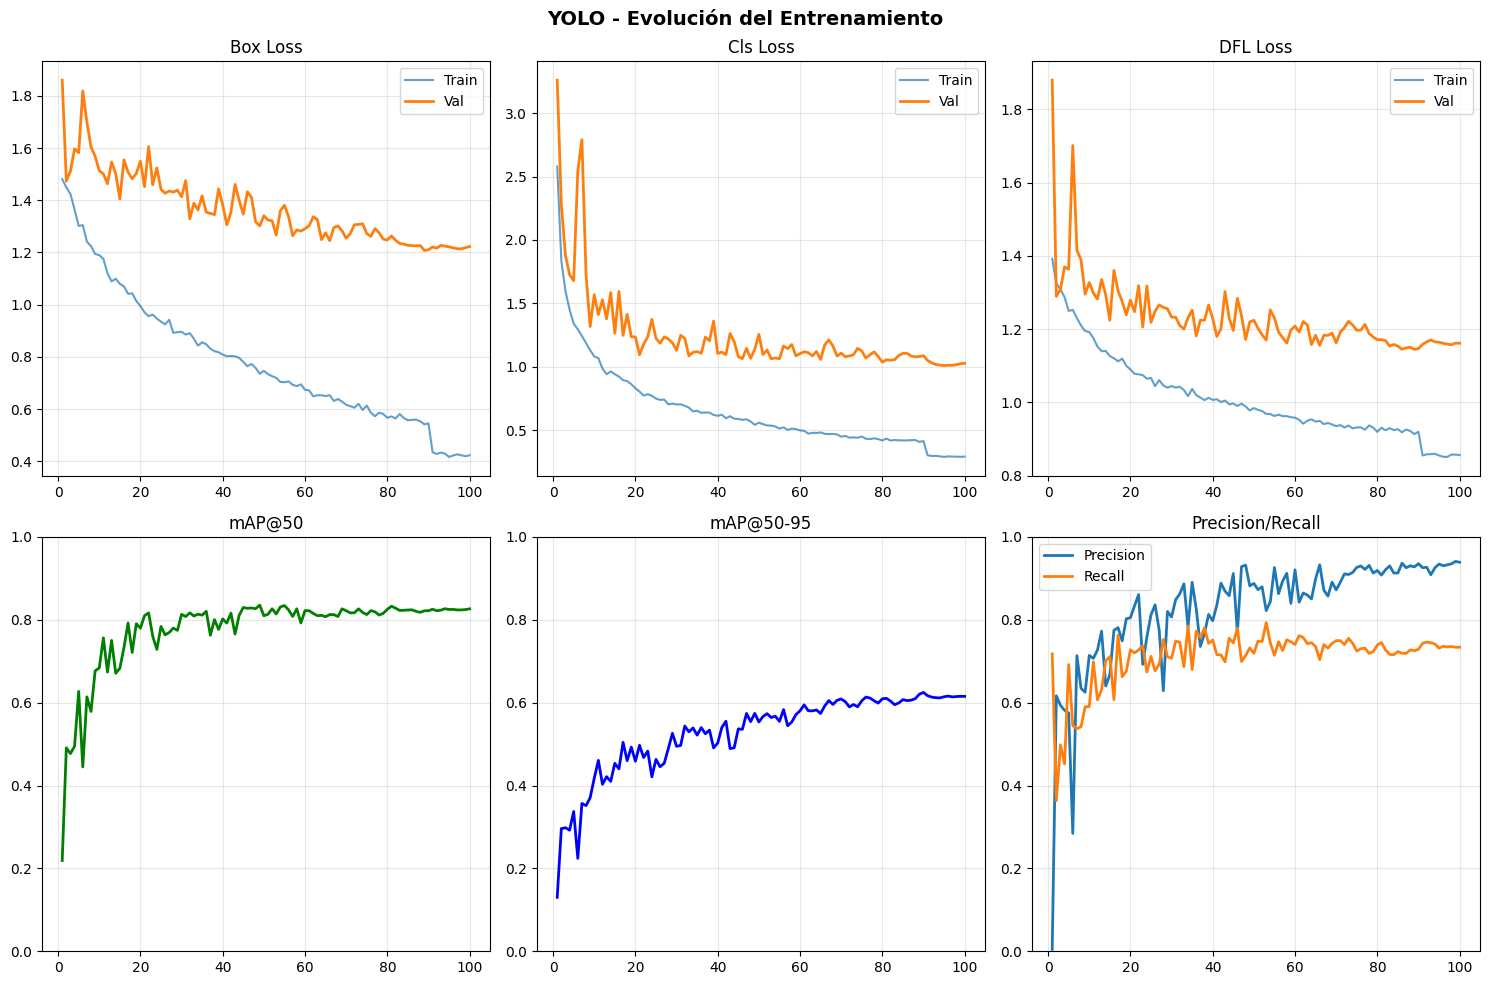

✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/yolo_v1_training.png


In [21]:
# Extracción de métricas y gráficos YOLO
yolo_results_dir = os.path.join(config.dirs["logs"], "yolo_v1")
yolo_hist_df = extract_yolo_metrics(yolo_results_dir, config.dirs["logs"], version_tag="yolo_v1")
if yolo_hist_df is not None:
    yolo_plot_path = os.path.join(config.dirs["visuals"], "yolo_v1_training.png")
    plot_yolo_history(yolo_hist_df, save_path=yolo_plot_path)

## Paso 4.1 — Evaluación en test (YOLOv11)

Evaluamos el modelo YOLO en el conjunto de test y calculamos métricas.

In [ ]:
# Evaluación YOLO en test
import importlib
import utils_yolo_infer as _yolo_infer
from utils_eval import evaluate_model

importlib.reload(_yolo_infer)
from utils_yolo_infer import load_yolo_model, run_yolo_inference

yolo_best_path = os.path.join(config.dirs["models_chk"], "yolo_v1_best.pt")
if not os.path.exists(yolo_best_path):
    raise FileNotFoundError(f"No se encontró el modelo YOLO: {yolo_best_path}")

yolo_model = load_yolo_model(yolo_best_path)

yolo_results = []
for images, gts, ids in test_loader.iter_batches(batch_size=8):
    # YOLO espera imágenes en [0,255] uint8 o float, aquí usamos RGB ya resize
    batch_results = run_yolo_inference(
        model=yolo_model,
        image_batch=images, # type: ignore
        class_names=CLASS_NAMES,
        image_ids=ids, # type: ignore
        ground_truths=gts,  # type: ignore
        model_name="yolo_v1",
        conf_threshold=0.25,
        iou_threshold=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    )
    yolo_results.extend(batch_results)

yolo_metrics = evaluate_model("yolo_v1", yolo_results, CLASS_NAMES)
print("\n📊 YOLO Test Metrics")
print(f"mAP@50: {yolo_metrics.map_50:.4f}")
print(f"Precision: {yolo_metrics.precision:.4f} | Recall: {yolo_metrics.recall:.4f} | F1: {yolo_metrics.f1_score:.4f}")
print(f"Detection Acc: {yolo_metrics.detection_accuracy:.4f} | Avg IoU: {yolo_metrics.avg_iou:.4f}")
print(f"Avg Inference Time (ms/img): {yolo_metrics.inference_time_ms:.2f}")


📊 YOLO Test Metrics
mAP@50: 0.0000
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Detection Acc: 0.0238 | Avg IoU: 0.0000
Avg Inference Time (ms/img): 10.38


## Paso 4.2 — Visualizador de muestras (YOLO)

Muestra detecciones YOLO en imágenes del test set.

Predicciones YOLO en muestras: 5


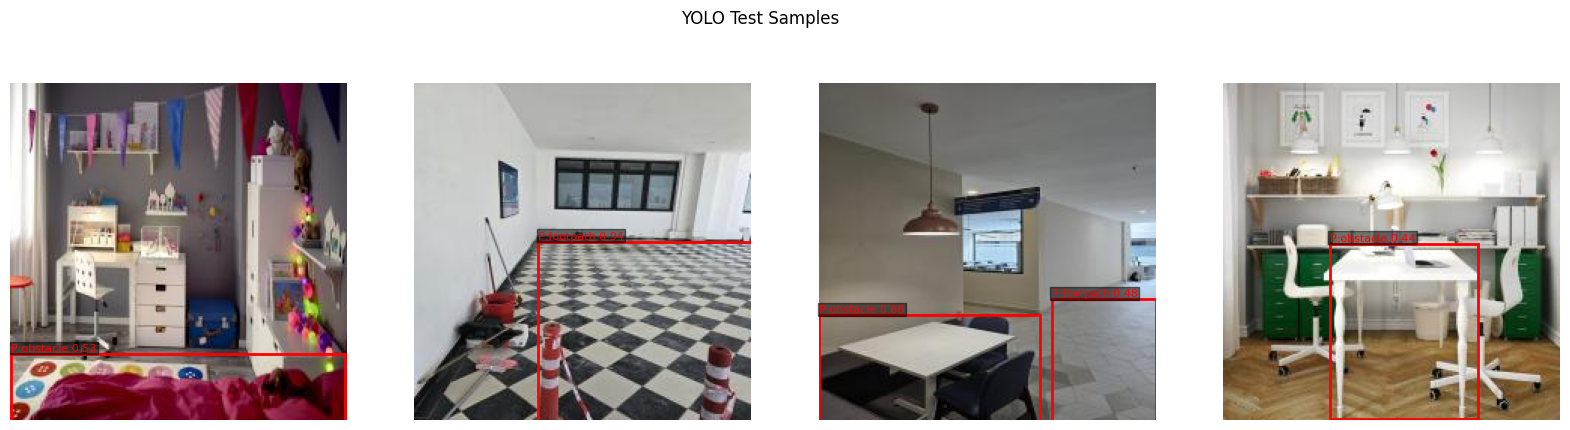

In [ ]:
# Visualizar detecciones YOLO en algunas imágenes
import importlib
import utils_yolo_infer as _yolo_infer
from utils_viz import show_random_samples

importlib.reload(_yolo_infer)
from utils_yolo_infer import run_yolo_inference

yolo_sample_images = []
yolo_sample_gts = []
yolo_sample_preds = []
yolo_total_preds = 0
for images, gts, ids in test_loader.iter_batches(batch_size=4):
    batch_results = run_yolo_inference(
        model=yolo_model,
        image_batch=images, # type: ignore
        class_names=CLASS_NAMES,
        image_ids=ids, # type: ignore
        ground_truths=gts,  # type: ignore
        model_name="yolo_v1",
        conf_threshold=0.25,
        iou_threshold=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    )
    for i in range(len(images)): # type: ignore
        yolo_sample_images.append(images[i]) # type: ignore
        yolo_sample_gts.append(gts[i]) # type: ignore
        yolo_sample_preds.append(batch_results[i].predictions)
        yolo_total_preds += len(batch_results[i].predictions)
    if len(yolo_sample_images) >= 4:
        break

print(f"Predicciones YOLO en muestras: {yolo_total_preds}")
show_random_samples(yolo_sample_images, yolo_sample_gts, yolo_sample_preds, max_samples=4, title="YOLO Test Samples")

## Paso 5 — Comparativas avanzadas

Análisis comparativo avanzado entre SSD y YOLO: métricas globales, matriz de confusión, dispersión por tamaño y análisis de errores.

In [34]:
# Tabla comparativa de métricas globales
from utils_compare import build_comparison_table

compare_df = build_comparison_table(ssd_metrics, yolo_metrics)
compare_df

,model,mAP@50,precision,recall,f1,det_acc,avg_iou,time_ms
0,SSD,0.0,0.0,0.0,0.0,0.571429,0.0,15.424428
1,YOLO,0.0,0.0,0.0,0.0,0.023810,0.0,10.383728


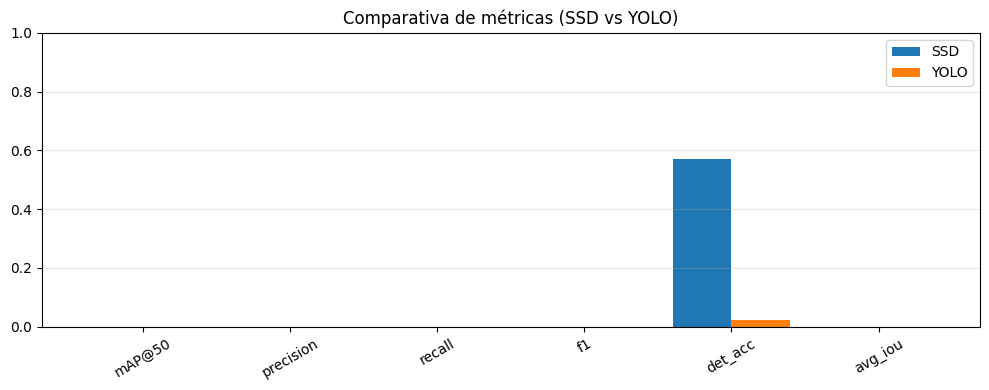

In [35]:
# Comparativa visual de métricas
from utils_compare import plot_metric_comparison

plot_metric_comparison(compare_df)

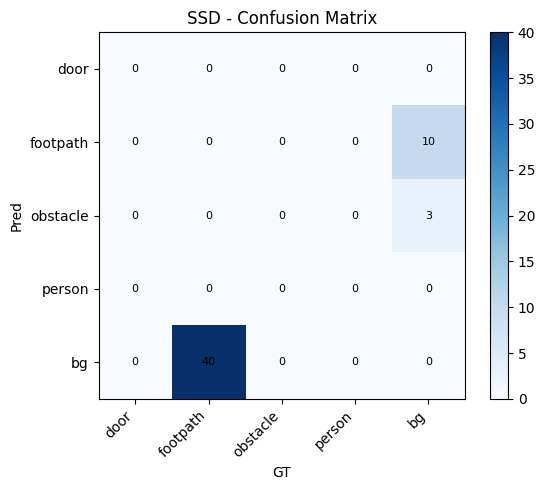

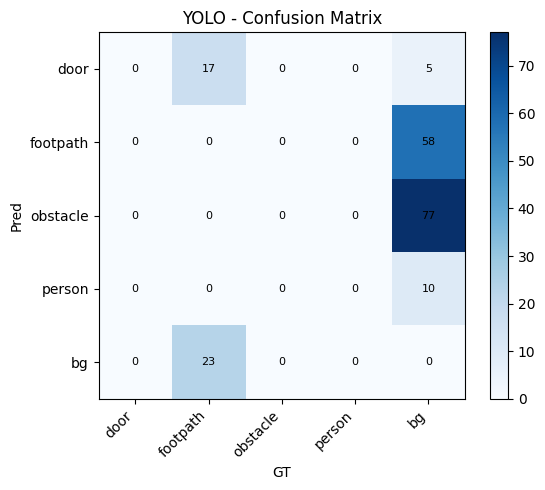

In [36]:
# Matrices de confusión
from utils_compare import plot_confusion_matrices

plot_confusion_matrices(ssd_metrics, yolo_metrics, CLASS_NAMES)

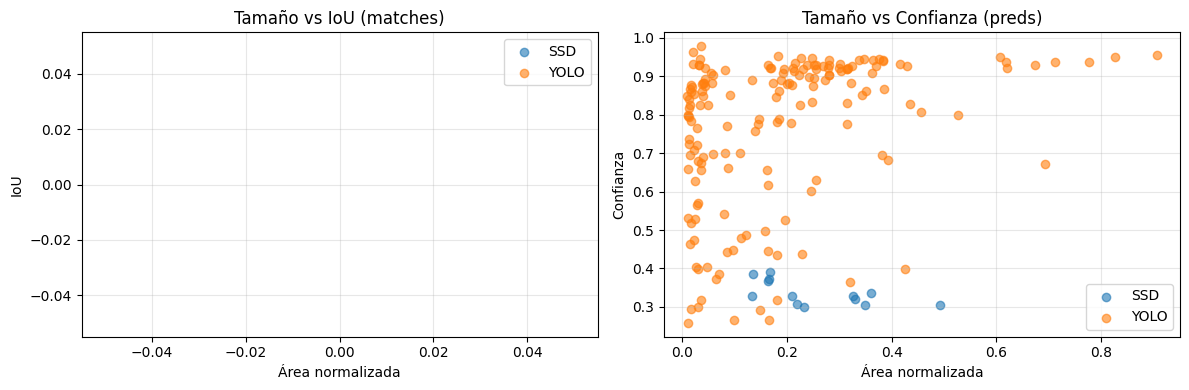

In [37]:
# Dispersión: tamaño vs IoU (matches) y tamaño vs confianza (preds)
from utils_compare import plot_size_scatter

plot_size_scatter(ssd_results, yolo_results, (TEST_IMG_SIZE, TEST_IMG_SIZE))

SSD FP/FN: 5 5
YOLO FP/FN: 5 5

SSD - False Positives (mostrando 3)


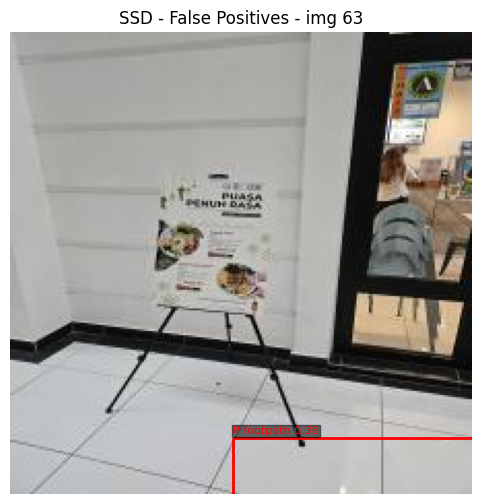

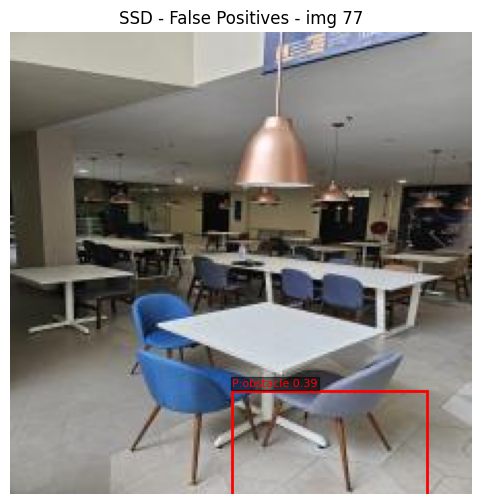

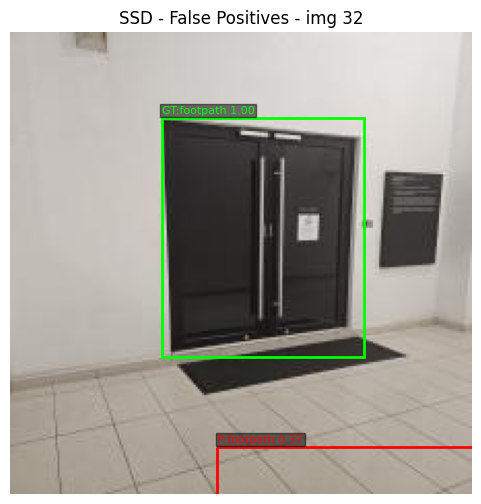


SSD - False Negatives (mostrando 3)


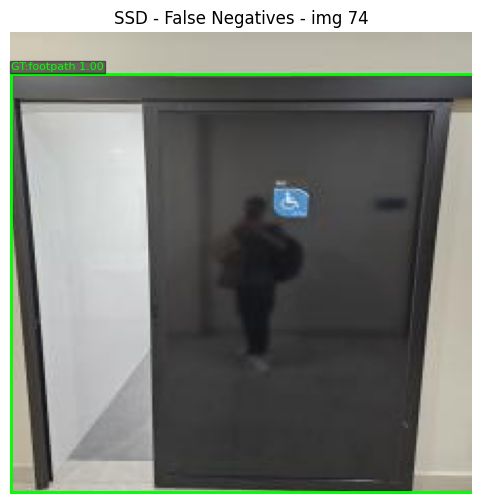

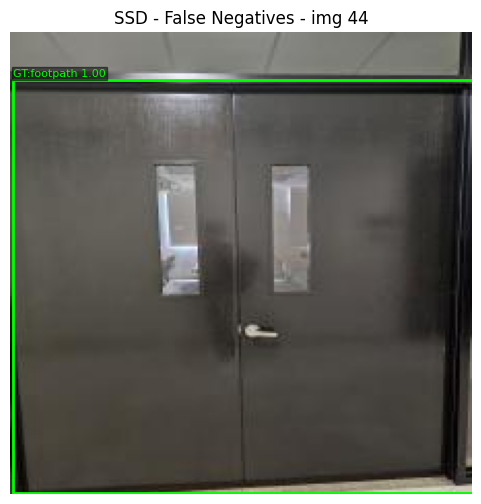

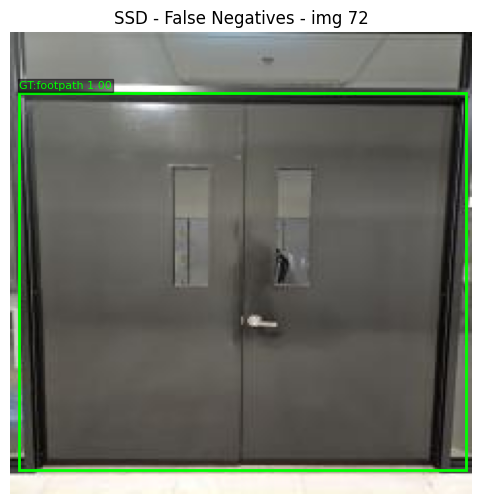


YOLO - False Positives (mostrando 3)


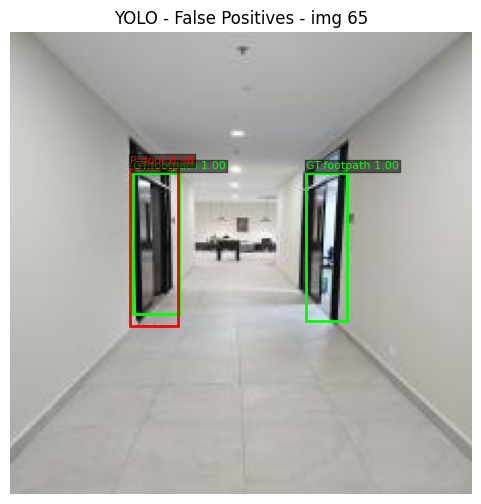

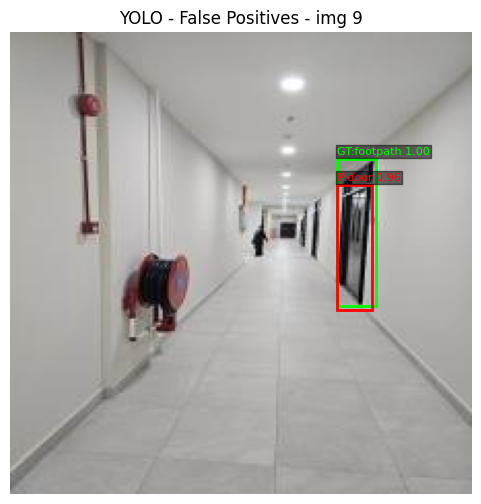

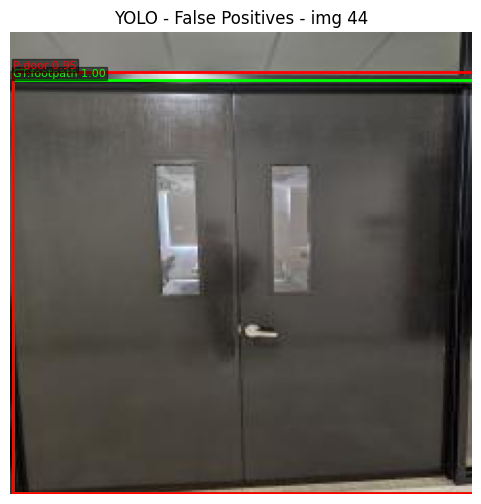


YOLO - False Negatives (mostrando 3)


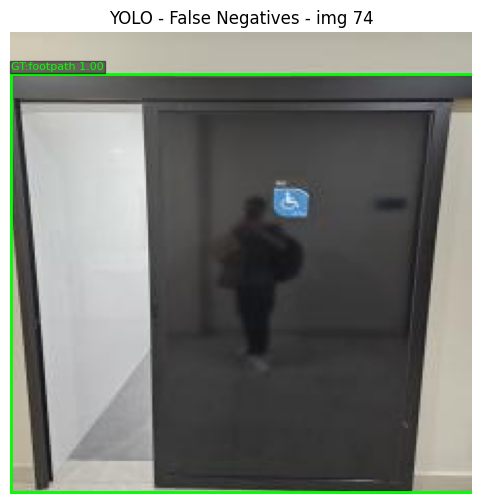

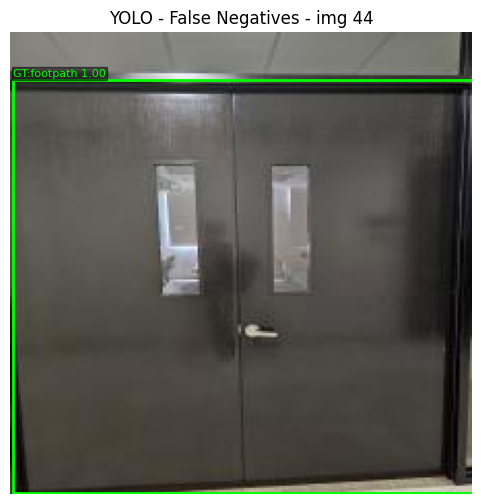

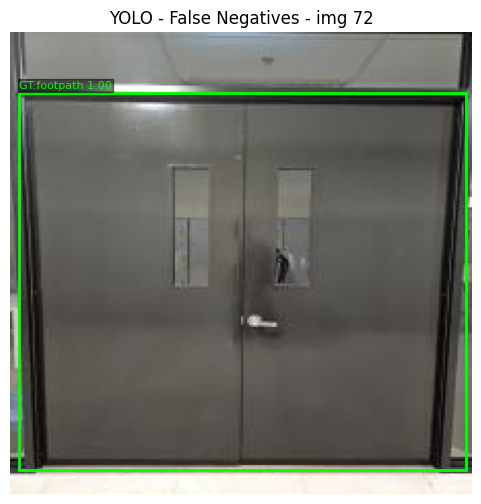

In [38]:
# Análisis de errores: FP/FN y visualización rápida
from utils_compare import run_error_analysis

run_error_analysis(
    ssd_results=ssd_results,
    yolo_results=yolo_results,
    test_loader=test_loader,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    iou_threshold=0.5,
    top_k=5,
)

## Paso 6 — Matriz de evaluación final

Matriz final de decisión con dimensiones normalizadas (precisión, velocidad, robustez, complejidad) y score global.

Base de complejidad: time_ms


,model,precision_score,speed_score,robustness_score,complexity_score,overall_score
0,SSD,0.0,0.0,0.571429,0.0,0.114286
1,YOLO,0.0,1.0,0.023810,1.0,0.404762


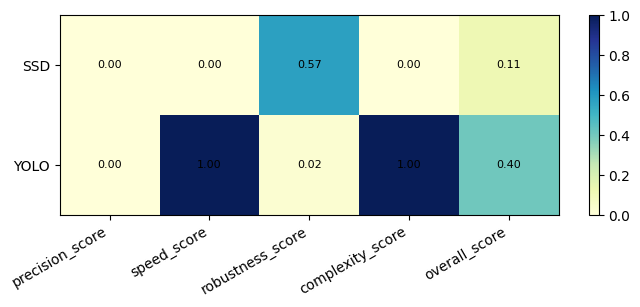

In [44]:
# Matriz final de evaluación
import importlib
import utils_compare
importlib.reload(utils_compare)
from utils_compare import build_final_evaluation_matrix, plot_final_matrix

final_df = build_final_evaluation_matrix(ssd_metrics, yolo_metrics)
print("Base de complejidad:", final_df.attrs.get("complexity_basis"))
display(final_df)
plot_final_matrix(final_df)